<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_06_normal_equations_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6: Ecuación normal

## Objetivo

Derivar e implementar la solución cerrada de un problema de regresión lineal multivariada mediante la ecuación normal, comparar con el ajuste numérico y estudiar una interpretación probabilística con regularización.

## Contexto matemático

En regresión lineal multivariada se modela la relación entre una variable objetivo $y$ y un conjunto de características $x_1, x_2, \dots, x_n$ mediante:

$$h_\theta(X) = \theta^T X$$Si $X \in \mathbb{R}^{(n+1) \times m}$ incluye una fila de unos para el sesgo, la función de costo cuadrática puede escribirse como:$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left(h_\theta(x^{(i)}) - y^{(i)}\right)^2$$La solución analítica que minimiza esta función, cuando $X^T X$ es invertible, está dada por la ecuación normal:$$\theta = (X^T X)^{-1} X^T y$$Si la matriz no es invertible, puede usarse la pseudoinversa o una versión regularizada tipo Ridge.

## Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

## 1. Ejemplo sintético: ajuste de un plano

Generamos datos en dos dimensiones para verificar que la ecuación normal recupera los parámetros verdaderos.

In [2]:
N = 100
x1 = 2 * np.random.random(N) - 1
x2 = 2 * np.random.random(N) - 1
noise = 0.05 * np.random.randn(N)
y = 0.2 * x1 - 0.5 * x2 + noise

df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})
df.head()

,x1,x2,y
0,-0.250920,-0.937142,0.384386
1,0.901429,0.272821,0.055488
2,0.463988,-0.371288,0.293095
3,0.197317,0.017141,-0.004825
4,-0.687963,0.815133,-0.451870


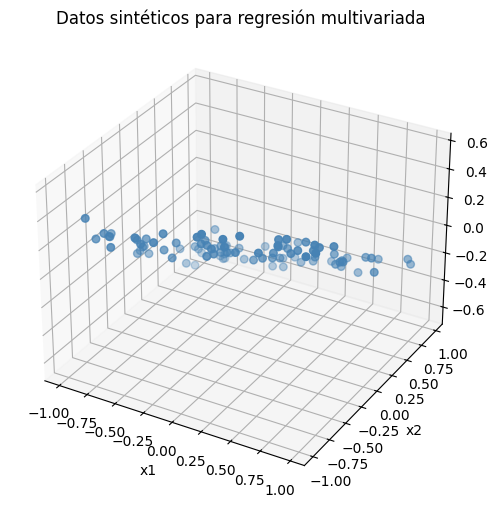

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['x1'], df['x2'], df['y'], c='steelblue', s=30)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('Datos sintéticos para regresión multivariada')
plt.show()

## 2. Construcción matricial

Agregamos una columna de unos para representar el sesgo y formamos la matriz de diseño.

In [4]:
X = np.c_[np.ones(N), df['x1'].values, df['x2'].values]
Y = df['y'].values.reshape(-1, 1)

print('Dimensión de X:', X.shape)
print('Dimensión de Y:', Y.shape)

Dimensión de X: (100, 3)
Dimensión de Y: (100, 1)


## 3. Ecuación normal

La solución cerrada se obtiene directamente por la expresión $heta = (X^TX)^{-1}X^Ty$. En caso de problemas numéricos, también puede usarse la pseudoinversa.

In [5]:
theta_normal = np.linalg.inv(X.T @ X) @ X.T @ Y
theta_pinv = np.linalg.pinv(X) @ Y

print('Theta por ecuación normal:')
print(theta_normal.ravel())
print('Theta por pseudoinversa:')
print(theta_pinv.ravel())

Theta por ecuación normal:
[ 0.00497015  0.19145687 -0.48201721]
Theta por pseudoinversa:
[ 0.00497015  0.19145687 -0.48201721]


In [6]:
y_pred_normal = X @ theta_normal
rmse_normal = mean_squared_error(Y, y_pred_normal, squared=False)
r2_normal = r2_score(Y, y_pred_normal)

print(f'RMSE ecuación normal: {rmse_normal:.6f}')
print(f'R2 ecuación normal: {r2_normal:.6f}')

RMSE ecuación normal: 0.048623
R2 ecuación normal: 0.975482


c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [7]:
lin_reg = LinearRegression()
lin_reg.fit(df[['x1', 'x2']], df['y'])

theta_sklearn = np.r_[lin_reg.intercept_, lin_reg.coef_]
print('Theta sklearn:')
print(theta_sklearn)

y_pred_sk = lin_reg.predict(df[['x1', 'x2']]).reshape(-1, 1)
rmse_sk = mean_squared_error(Y, y_pred_sk, squared=False)
r2_sk = r2_score(Y, y_pred_sk)

print(f'RMSE sklearn: {rmse_sk:.6f}')
print(f'R2 sklearn: {r2_sk:.6f}')

Theta sklearn:
[ 0.00497015  0.19145687 -0.48201721]
RMSE sklearn: 0.048623
R2 sklearn: 0.975482


c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


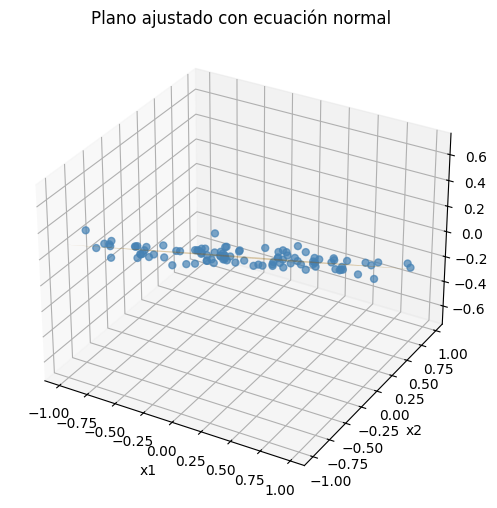

In [8]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['x1'], df['x2'], df['y'], c='steelblue', s=25, alpha=0.7)

grid_x1 = np.linspace(df['x1'].min(), df['x1'].max(), 20)
grid_x2 = np.linspace(df['x2'].min(), df['x2'].max(), 20)
X1g, X2g = np.meshgrid(grid_x1, grid_x2)
Yg = theta_normal[0] + theta_normal[1] * X1g + theta_normal[2] * X2g
ax.plot_surface(X1g, X2g, Yg, alpha=0.35, color='orange')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('Plano ajustado con ecuación normal')
plt.show()

## 4. Interpretación probabilística

Si suponemos que los errores siguen una distribución gaussiana, maximizar la verosimilitud es equivalente a minimizar el error cuadrático medio. Esto justifica el uso de mínimos cuadrados como criterio de ajuste.

## 5. Dataset de Boston Housing

Ahora aplicamos la misma idea a un conjunto de datos real. Para reducir la complejidad, usamos solo una variable explicativa: el número promedio de habitaciones por vivienda (`rm`). El objetivo es predecir el valor medio de la vivienda (`mean_`).

In [9]:
data_url = 'http://lib.stat.cmu.edu/datasets/boston'
raw_df = pd.read_csv(data_url, sep='\s+', skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

df_boston = pd.DataFrame({'mean_': target, 'rm': data[:, 5]})
df_boston.head()

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Biohealthy\AppData\Local\Temp\ipykernel_1160\4025515340.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep='\s+', skiprows=22, header=None)


,mean_,rm
0,24.0,6.575
1,21.6,6.421
2,34.7,7.185
3,33.4,6.998
4,36.2,7.147


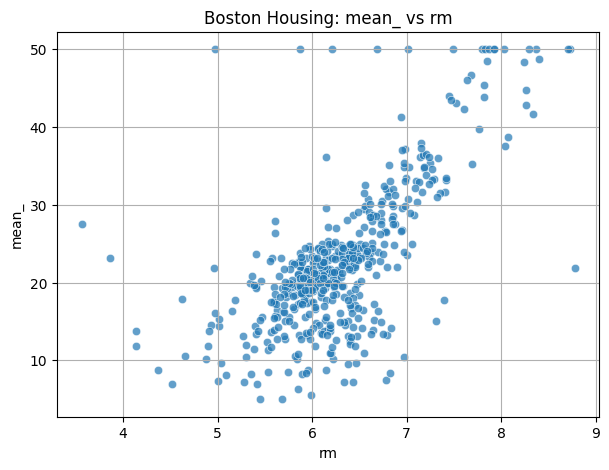

In [10]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_boston, x='rm', y='mean_', alpha=0.7)
plt.title('Boston Housing: mean_ vs rm')
plt.show()

In [11]:
Xb = np.c_[np.ones(len(df_boston)), df_boston['rm'].values]
Yb = df_boston['mean_'].values.reshape(-1, 1)

theta_boston = np.linalg.pinv(Xb) @ Yb
print('Theta Boston:')
print(theta_boston.ravel())

y_pred_boston = Xb @ theta_boston
rmse_boston = mean_squared_error(Yb, y_pred_boston, squared=False)
r2_boston = r2_score(Yb, y_pred_boston)

print(f'RMSE Boston: {rmse_boston:.6f}')
print(f'R2 Boston: {r2_boston:.6f}')

Theta Boston:
[-34.67062078   9.10210898]
RMSE Boston: 6.603071
R2 Boston: 0.483525


c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


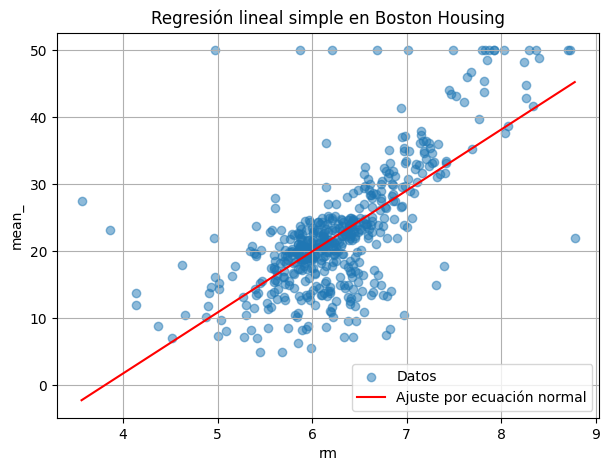

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(df_boston['rm'], df_boston['mean_'], alpha=0.5, label='Datos')
rm_grid = np.linspace(df_boston['rm'].min(), df_boston['rm'].max(), 200)
mean_grid = theta_boston[0] + theta_boston[1] * rm_grid
plt.plot(rm_grid, mean_grid, color='red', label='Ajuste por ecuación normal')
plt.xlabel('rm')
plt.ylabel('mean_')
plt.title('Regresión lineal simple en Boston Housing')
plt.legend()
plt.show()

## 6. Regularización (Ridge)

Cuando el sistema es mal condicionado o hay multicolinealidad, una regularización tipo Ridge estabiliza la solución. La versión regularizada de la ecuación normal es:

$$
\theta = (X^TX + \lambda I)^{-1}X^Ty.
$$

In [13]:
lambda_ = 1.0
I = np.eye(X.shape[1])
I[0, 0] = 0.0
theta_ridge = np.linalg.inv(X.T @ X + lambda_ * I) @ X.T @ Y

print('Theta Ridge:')
print(theta_ridge.ravel())

ridge_model = Ridge(alpha=lambda_, fit_intercept=False)
ridge_model.fit(X, Y)
print('Theta Ridge sklearn:')
print(ridge_model.coef_.ravel())

Theta Ridge:
[ 0.00473881  0.18658878 -0.4684173 ]
Theta Ridge sklearn:
[ 0.00469142  0.18658099 -0.46841814]


## 7. Comparación de modelos

Comparamos la solución analítica, la regresión lineal de sklearn y la versión regularizada. La idea es verificar consistencia numérica y observar el efecto de la penalización.

c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,Modelo,RMSE,R2
0,Ecuación normal,0.048623,0.975482
1,Sklearn lineal,0.048623,0.975482
2,Ridge,0.049366,0.974727


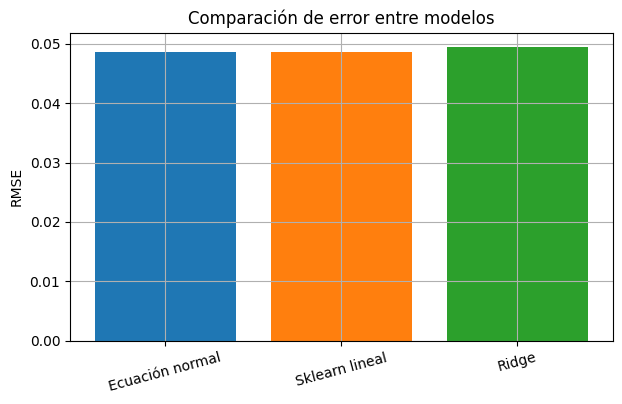

In [14]:
comparacion = pd.DataFrame({
    'Modelo': ['Ecuación normal', 'Sklearn lineal', 'Ridge'],
    'RMSE': [rmse_normal, rmse_sk, mean_squared_error(Y, X @ theta_ridge, squared=False)],
    'R2': [r2_normal, r2_sk, r2_score(Y, X @ theta_ridge)]
})
display(comparacion)

plt.figure(figsize=(7, 4))
plt.bar(comparacion['Modelo'], comparacion['RMSE'], color=['tab:blue', 'tab:orange', 'tab:green'])
plt.ylabel('RMSE')
plt.title('Comparación de error entre modelos')
plt.xticks(rotation=15)
plt.show()

## 8. Conclusiones

1. La ecuación normal proporciona una solución cerrada y exacta cuando la matriz es invertible.
2. La solución obtenida coincide con la de `LinearRegression` de sklearn.
3. En el conjunto de Boston, una sola variable explica parte de la variabilidad, pero no todo el fenómeno.
4. La regularización Ridge estabiliza la estimación cuando el problema está mal condicionado.
5. La formulación matricial simplifica la implementación y la interpretación del modelo.